In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path


def load_results(file_path):
    """
    Load results from a pickle file.

    Args:
        file_path (str): Path to the pickle file.

    Returns:
        dict: Dictionary containing the loaded results.
    """
    try:
        with open(file_path, 'rb') as f:
            results = pickle.load(f)
        return results
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


def get_train_metrics(results):
    """
    Extract training metrics from the results dictionary.

    Args:
        results (dict): Dictionary containing training history.

    Returns:
        dict: Dictionary containing lists of training metrics.
    """
    train_metrics = {
        'obj': [],
        'loss': [],
        # 'opt_gap': [],
        'eq_violation_l1': [],
        'ineq_violation_l1': [],
        # 'distance': []
    }

    for k in range(len(results['train_history'])):
        for key in train_metrics.keys():
            train_metrics[key].append(results['train_history'][k][key])

    return train_metrics

# dict_keys(['val_history', 'test_results'])
# dict_keys(['epoch', 'opt_gap_mean', 'opt_gap_std', 'opt_gap_max',
#            'eq_violation_l1_mean', 'eq_violation_l1_max',
#            'ineq_violation_l1_mean', 'ineq_violation_l1_max'])


def get_val_metrics(results):
    """
    Extract validation metrics from the results dictionary.

    Args:
            results (dict): Dictionary containing validation history.

    Returns:
            dict: Dictionary containing lists of validation metrics.
    """
    val_metrics = {
        'opt_gap_mean': [],
        'opt_gap_std': [],
        'opt_gap_max': [],
        'eq_violation_l1_mean': [],
        'eq_violation_l1_max': [],
        'ineq_violation_l1_mean': [],
        'ineq_violation_l1_max': [],
        'merit_mean': [],
        'merit_max': []
    }

    for k in range(len(results['val_history'])):
        for key in val_metrics.keys():
            val_metrics[key].append(results['val_history'][k][key])

    # compute merit
    for k in range(len(results['val_history'])):
        val_metrics['merit_mean'][k] = (
            results['val_history'][k]['objective'] + 1e5 * (results['val_history'][k]['eq_violation_l1_mean'] + results['val_history'][k]['ineq_violation_l1_mean'])
        )
        val_metrics['merit_max'][k] = (
            results['val_history'][k]['objective_max'] + 1e5 * (results['val_history'][k]['eq_violation_l1_max'] + results['val_history'][k]['ineq_violation_l1_max'])
        )
    return val_metrics

In [3]:
from pathlib import Path

base = Path.cwd()

# filename = "20260115-184556_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_3.0"
# filename = "20260327-114339_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_3.0"
filename = "20260327-094852_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_2.0"

path = base / "results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000" / \
    filename / "results.pkl"

results = load_results(path)

In [4]:
results.keys()  # dict_keys(['train_history', 'val_history', 'test_results'])

dict_keys(['seed', 'method', 'config', 'timestamp', 'training_time_seconds', 'train_history', 'val_history', 'test_results', 'pytorch_version', 'device_used'])

In [5]:
results['test_results']['batch_size_comparison'][256]['metrics']['true_objective']  # 11.688

np.float64(-2.4092202940404004)

In [44]:
len(val_metrics['merit_mean'])
len(x_val[1:])

99

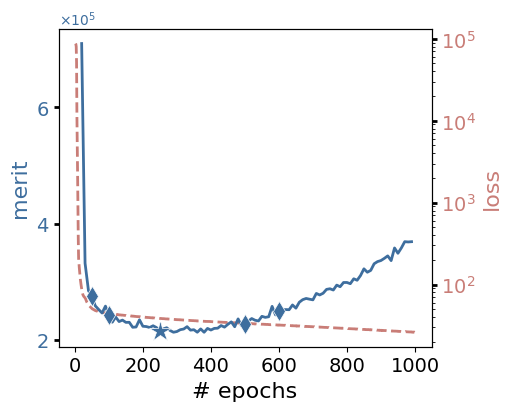

In [186]:
val_metrics = get_val_metrics(results)
train_metrics = get_train_metrics(results)

FONT_SIZE = 16
WIDTH = 2

# Data extraction
x_val = [entry['epoch'] for entry in results['val_history']]
x_train = [entry['epoch'] for entry in results['train_history']]

from matplotlib.ticker import ScalarFormatter
# Set global font/style for publication

fig, ax1 = plt.subplots(figsize=(5, 4), constrained_layout=True)

# Data extraction (assumed from previous context)
# x_val, x_train, val_metrics, train_metrics = ...

# Primary Axis (Merit)
color1 = "#3E6E9E"  
ax1.set_xlabel('# epochs', fontsize=FONT_SIZE)
ax1.set_ylabel('merit', color=color1, fontsize=FONT_SIZE)
ax1.plot(x_val[2:], val_metrics['merit_mean'][2:], color=color1, linewidth=2, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color1, width=WIDTH)
ax1.spines['top'].set_visible(True)
# ax1.set_yscale('log')
ax1.locator_params(axis="y", nbins=4)
# ax1.grid(True, which='major', axis='x', linestyle=':', alpha=0.3)

# Force scientific notation: 10^5
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((5, 5))
ax1.yaxis.set_major_formatter(formatter)
ax1.yaxis.get_offset_text().set_fontsize(10)
ax1.yaxis.get_offset_text().set_position((1.02, 1))

# marker at 50, 100, 250, 500, 800
markers = [5, 10, 50, 60]
for marker in markers:
    ax1.plot(marker*10, val_metrics['merit_mean'][marker], color=color1, linewidth=5, marker="d", markersize=10, markeredgewidth=WIDTH-1.5, markeredgecolor='white')
ax1.plot(250, val_metrics['merit_mean'][25], color=color1, linewidth=5, marker="*", markersize=16, markeredgewidth=WIDTH-1.5, markeredgecolor='white')
# Secondary Axis (Loss)
ax2 = ax1.twinx()
color2 = "#C97D77"  
ax2.set_ylabel('loss', color=color2, fontsize=FONT_SIZE)
ax2.plot(x_train[2:], train_metrics['loss'][2:],
         color=color2, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2, width=WIDTH)
ax2.spines['top'].set_visible(True)
ax2.set_yscale('log')
ax1.set_zorder(ax2.get_zorder() + 1)
ax1.patch.set_visible(False)

# Ensure white background explicitly
fig.patch.set_facecolor('white')

plt.show()

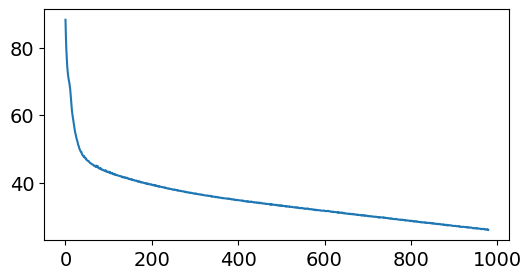

In [178]:
# draw only the merit
plt.figure(figsize=(6, 3))
plt.plot(train_metrics['loss'][20:])
# plt.yscale('log')

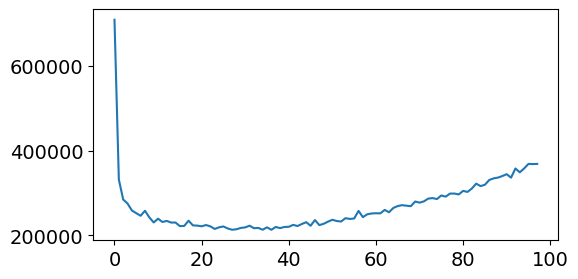

In [179]:
# draw only the merit
plt.figure(figsize=(6, 3))
plt.plot(val_metrics['merit_mean'][2:])
# plt.yscale('log')

In [180]:
# pick the checkpoints right before the merit cannot decrease more than 5% for 10 consecutive times
merit_mean = val_metrics['merit_mean']
best_epoch = 0
best_merit = merit_mean[0]
no_improve_count = 0
for epoch in range(1, len(merit_mean)):
    if merit_mean[epoch] < 0.95 * best_merit:
        best_merit = merit_mean[epoch]
        best_epoch = epoch
        no_improve_count = 0
    else:
        no_improve_count += 1
    if no_improve_count >= 10:
        break
print(
    f"Best epoch: {results['val_history'][best_epoch]['epoch']}, Best merit: {best_merit}")
print(
    f"Last epoch evaluated: {results['val_history'][-1]['epoch']}, {merit_mean[-1]}")

Best epoch: 250, Best merit: 215156.12428588682
Last epoch evaluated: 990, 369010.3601494106


In [181]:
# find smalles index in merit_mean
min_idx = merit_mean.index(min(merit_mean))
print(results['val_history'][min_idx]['epoch'], merit_mean[min_idx])

380 213205.81946064238


In [182]:
28308 / 480

58.975

In [183]:
# Get batch comparison data from the loaded results
batch_comparison = results['test_results']['batch_size_comparison']

# Create a more readable DataFrame by expanding the metrics
readable_data = []
for batch_size, data in batch_comparison.items():
    metrics = data['metrics']
    row = {
        'Batch Size': batch_size,
        'Opt Gap Mean': f"{metrics['opt_gap_mean']:.2%}",
        # 'Opt Gap Std': f"{metrics['opt_gap_std']:.4f}",
        # 'Opt Gap Max': f"{metrics['opt_gap_max']:.4f}",
        'Eq Violation Mean': f"{metrics['eq_violation_l1_mean']:.2e}",
        # 'Eq Violation Max': f"{metrics['eq_violation_l1_max']:.2e}",
        'Ineq Violation Mean': f"{metrics['ineq_violation_l1_mean']:.2e}",
        # 'Ineq Violation Max': f"{metrics['ineq_violation_l1_max']:.2e}",
        'Average Batch Time (s)': f"{metrics['avg_inference_time']:.4f}",
    }
    readable_data.append(row)

df_readable = pd.DataFrame(readable_data)
df_readable_styled = df_readable.style.set_properties(
    **{'text-align': 'center'})
display(df_readable_styled)

,Batch Size,Opt Gap Mean,Eq Violation Mean,Ineq Violation Mean,Average Batch Time (s)
0,256,6742.64%,2.49e+00,1.41e+00,0.0002
1,512,6701.34%,2.49e+00,1.41e+00,0.0002
